<a href="https://colab.research.google.com/github/shanmugt-hub/ann/blob/main/LSTM_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import math
from sklearn.metrics import mean_squared_error
from keras.layers import LSTM, Dense, Dropout
from keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [2]:
def plot_predictions(real_prices, predicted_prices):
    plt.figure(figsize=(16, 6))
    plt.plot(real_prices, color='green', label='Actual IBM Stock Price')
    plt.plot(predicted_prices, color='orange',
             label='Predicted IBM Stock Price')
    plt.title('IBM Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('Stock Price')
    plt.legend()
    plt.show()

In [3]:
def calculate_rmse(real_prices, predicted_prices):
    rmse = math.sqrt(mean_squared_error(real_prices, predicted_prices))
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
dataset = pd.read_csv("/content/drive/MyDrive/AIML/ANN/IBM_2006-01-01_to_2018-01-01.csv",
                      index_col='Date', parse_dates=['Date'])



In [11]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3020 entries, 2006-01-03 to 2017-12-29
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    3019 non-null   float64
 1   High    3020 non-null   float64
 2   Low     3019 non-null   float64
 3   Close   3020 non-null   float64
 4   Volume  3020 non-null   int64  
 5   Name    3020 non-null   object 
dtypes: float64(4), int64(1), object(1)
memory usage: 229.7+ KB


In [10]:
training_set = dataset.loc[:'2016', 'High'].values.reshape(-1, 1)
test_set = dataset.loc['2017':, 'High'].values.reshape(-1, 1)
display(dataset.head())

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,82.45,82.55,80.81,82.06,11715200,IBM
2006-01-04,82.20,82.50,81.33,81.95,9840600,IBM
2006-01-05,81.40,82.90,81.00,82.50,7213500,IBM
2006-01-06,83.95,85.03,83.41,84.95,8197400,IBM
2006-01-09,84.10,84.25,83.38,83.73,6858200,IBM


In [13]:
training_set.shape

(2769, 1)

In [23]:
training_set[1,0]

np.float64(82.5)

In [14]:
test_set.shape

(251, 1)

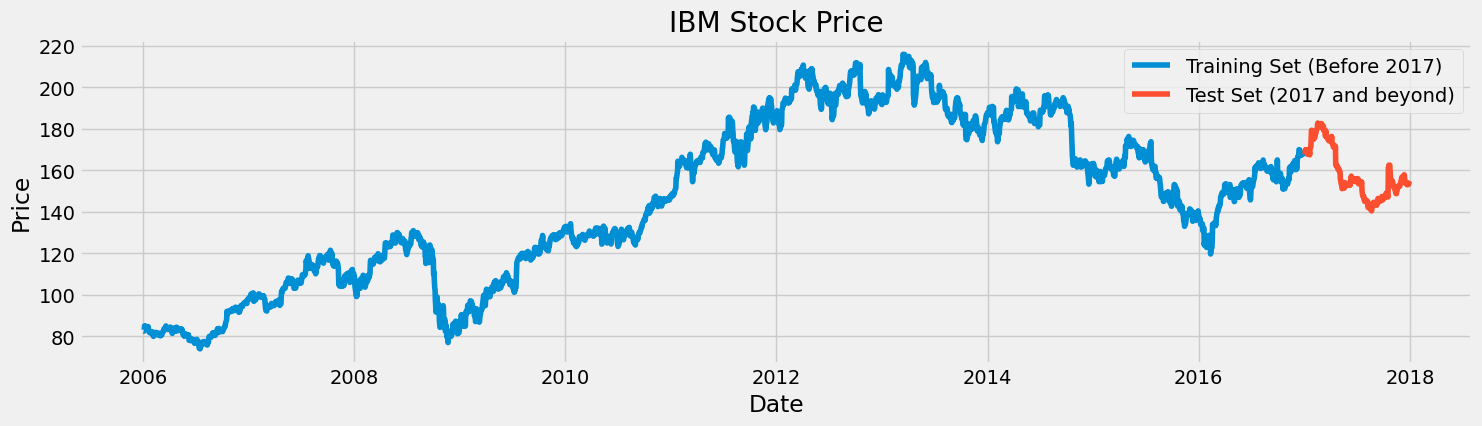

In [15]:
plt.figure(figsize=(16, 4))
plt.plot(dataset.loc[:'2016', 'High'], label='Training Set (Before 2017)')
plt.plot(dataset.loc['2017':, 'High'], label='Test Set (2017 and beyond)')
plt.title('IBM Stock Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

In [16]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_training = scaler.fit_transform(training_set)

In [22]:
scaled_training[1,0]

np.float64(0.06029867568329106)

In [24]:
X_train = []
y_train = []

for i in range(60, len(scaled_training)):
    X_train.append(scaled_training[i - 60:i, 0])
    y_train.append(scaled_training[i, 0])

X_train = np.array(X_train)
y_train = np.array(y_train)


In [28]:
X_train.shape

(2709, 60)

In [29]:
y_train.shape

(2709,)

In [30]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)

In [31]:
X_train.shape

(2709, 60, 1)

In [32]:
lstm_model = Sequential()

lstm_model.add(LSTM(units=50, return_sequences=True,
               input_shape=(X_train.shape[1], 1)))
lstm_model.add(Dropout(0.2))

lstm_model.add(LSTM(units=50, return_sequences=True))
lstm_model.add(Dropout(0.2))

lstm_model.add(LSTM(units=50, return_sequences=True))
lstm_model.add(Dropout(0.2))

lstm_model.add(LSTM(units=50))
lstm_model.add(Dropout(0.2))

lstm_model.add(Dense(units=1))

lstm_model.compile(optimizer='rmsprop', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [33]:
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
lstm_model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1)

Epoch 1/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 16s 120ms/step - loss: 0.0472
Epoch 2/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 104ms/step - loss: 0.0097
Epoch 3/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - loss: 0.0077
Epoch 4/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 121ms/step - loss: 0.0071
Epoch 5/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0058
Epoch 6/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 119ms/step - loss: 0.0058
Epoch 7/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 121ms/step - loss: 0.0051
Epoch 8/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - loss: 0.0049
Epoch 9/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - loss: 0.0041
Epoch 10/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 121ms/step - loss: 0.0044
Epoch 11/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - loss: 0.0039
Epoch 12/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - loss: 0.0037
Epoch 13/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 121ms/step - loss: 0.0036
Epoch 14/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 109ms/step - loss: 0.0037
Epoch 15/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/st

In [36]:
dataset_total = pd.concat(
    (dataset['High'][:'2016'], dataset['High']['2017':]), axis=0)
inputs = dataset_total[len(dataset_total) - len(test_set) - 60:].values


In [39]:
inputs = inputs.reshape(-1, 1)
inputs = scaler.transform(inputs)

In [40]:
X_test = []
for i in range(60, len(inputs)):
    X_test.append(inputs[i - 60:i, 0])

X_test = np.array(X_test)

In [41]:
X_test.shape

(251, 60)

In [42]:
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [43]:
X_test.shape

(251, 60, 1)

In [44]:
predicted_prices_scaled = lstm_model.predict(X_test)
predicted_prices = scaler.inverse_transform(predicted_prices_scaled)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step


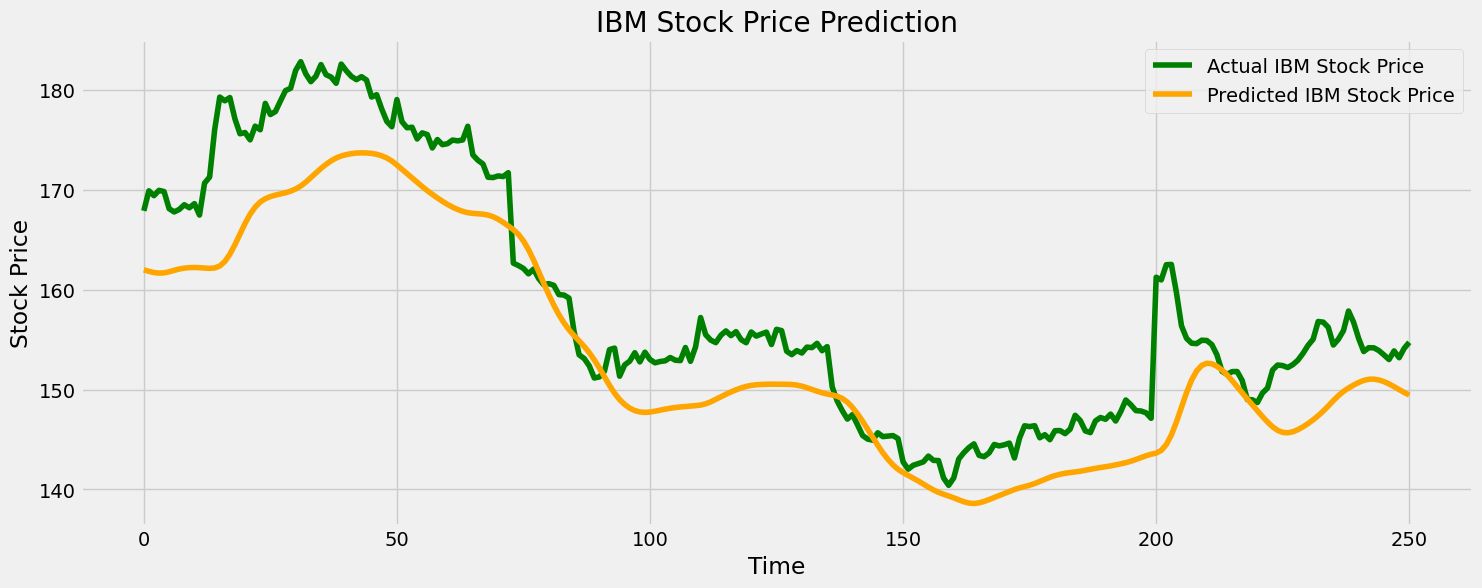

In [45]:
plot_predictions(test_set, predicted_prices)

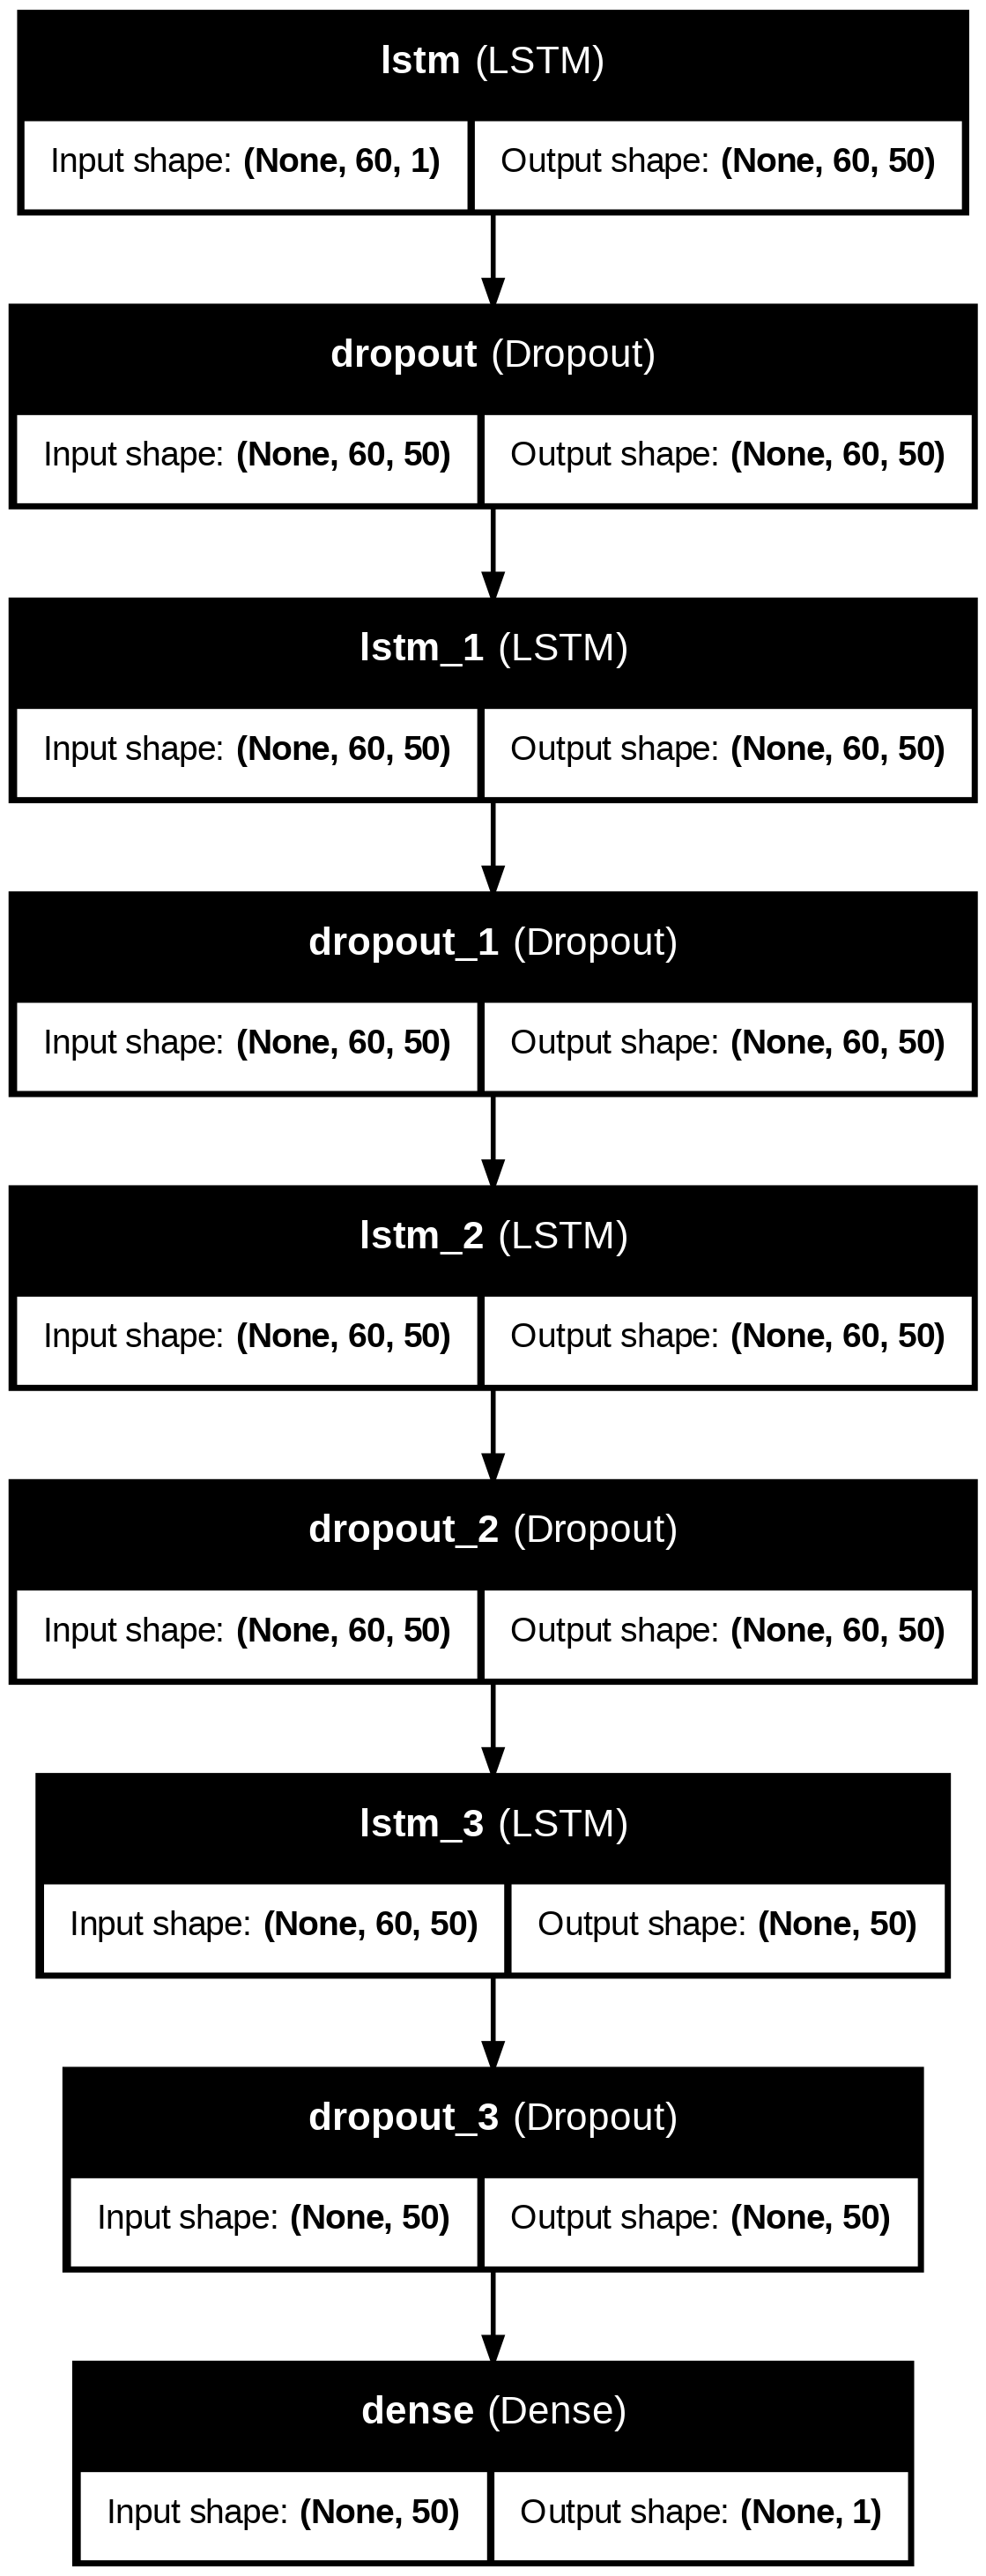

In [47]:
import tensorflow as tf
tf.keras.utils.plot_model(lstm_model, to_file='lstm_model.png', show_shapes=True, show_layer_names=True)

from IPython.display import Image
Image(filename='lstm_model.png')

In [46]:
calculate_rmse(test_set, predicted_prices)

Root Mean Squared Error (RMSE): 6.1826
